# HackOps: Red Agent Training Lab (RL + PPO)

This notebook provides a complete environment for training, evaluating, and visualizing **Reinforcement Learning (RL)** agents for the HackOps cybersecurity platform. We use **Stable-Baselines3 (PPO)** to train the Red Agent (Attacker) and compare it against a baseline randomly-acting agent.

### Goals:
1.  **Reproducibility**: Use fixed seeds and documented configurations.
2.  **Visualization**: Track training progress with interactive graphs.
3.  **Persistence**: Save models and training history for later use.
4.  **Comparison**: Benchmarking against a baseline model.

## 🛠️ Step 1: imports and Setup

We initialize the environment, set random seeds, and ensure the necessary directories exist.

In [1]:
import os
import sys
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

# RL Libraries
import torch
import gymnasium as gym
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from stable_baselines3.common.utils import set_random_seed
from sb3_contrib import RecurrentPPO
# Custom HackOps Integrations
from cyborg_integration import create_cyborg_env, RandomAttackAgent, DVWAFlatWrapper
import train_sb3

# Set seed for reproducibility
SEED = 42
set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Define paths
BASE_DIR = Path(os.getcwd())
MODELS_DIR = BASE_DIR / "models" / "red_agent"
LOGS_DIR = BASE_DIR / "logs" / "red_agent"
RESULTS_DIR = BASE_DIR / "results" / "red_agent"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Setup complete. Random Seed: {SEED}")
print(f"Models will be saved to: {MODELS_DIR}")
print(f"GPU Available: {torch.cuda.is_available()}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Setup complete. Random Seed: 42
Models will be saved to: d:\study\4th year 1st term\Graduation Project\hackops-project\api\models\red_agent
GPU Available: True


## 📊 Step 2: Establish Baseline Performance

Before training, we evaluate a **Random Agent** to see the starting performance level. This gives us a benchmark to beat.

In [2]:
print("Evaluating Random Baseline Agent...")
baseline_results = train_sb3.evaluate_random_baseline(
    agent_type='red', 
    n_episodes=50, 
    allowed_attacks=['XSS', 'SQL Injection']
)

# Save baseline results to JSON
with open(os.path.join(RESULTS_DIR, "baseline_results.json"), "w") as f:
    json.dump(baseline_results, f, indent=2)

print(f"\n📉 Baseline Mean Reward: {baseline_results['mean_reward']:.2f}")
print(f"📉 Baseline Mean Length: {np.mean(baseline_results['episode_lengths']):.1f}")

DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599


Evaluating Random Baseline Agent...

📊 Evaluating Random Baseline for RED (50 episodes)...

[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)


Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599


   Episode 10/50 completed


Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141599
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600


...

   Episode 30/50 completed


Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600
Using seed: 1775141600


   Episode 40/50 completed


Using seed: 1775141600
Using seed: 1775141601
Using seed: 1775141601
Using seed: 1775141601
Using seed: 1775141601
Using seed: 1775141601


   Episode 50/50 completed

✅ Baseline Evaluation Complete
   Mean Reward: 525.68 (+/- 703.23)
   Mean Length: 149.68

📉 Baseline Mean Reward: 525.68
📉 Baseline Mean Length: 149.7


## 🎓 Step 3: Configure & Start Training

We setup the environment and build the **PPO (Proximal Policy Optimization)** model.

In [ ]:
# Training Hyperparameters
TIMESTEPS = 200000
PPO_CONFIG = {
    'policy': 'MlpPolicy',
    'learning_rate': 0.0003,
    'n_steps': 2048,
    'batch_size': 64,
    'n_epochs': 10,
    'gamma': 0.99,
    'ent_coef': 0.05,
    'verbose': 0,
    'tensorboard_log': str(LOGS_DIR)
}

# Initialize environment
env = train_sb3.create_training_env(agent_type='red', allowed_attacks=['XSS', 'SQL Injection'])

# Create Model
model = PPO(env=env, **PPO_CONFIG)

# Setup Callbacks
checkpoint_callback = CheckpointCallback(
    save_freq=10000, 
    save_path=str(MODELS_DIR / "checkpoints"),
    name_prefix="red_agent"
)

class ProgressCallback(BaseCallback):
    def __init__(self, total_timesteps, verbose=0):
        super().__init__(verbose)
        self.pbar = None
        self.total_timesteps = total_timesteps
        self.history = []
        self.lengths = []
        self.episode_count = 0
        self.last_reward = 0
        
    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps, desc="Training Red Agent")
        
    def _on_step(self) -> bool:
        self.pbar.update(1)
        if 'episode' in self.locals['infos'][0]:
            self.episode_count += 1
            info = self.locals['infos'][0]['episode']
            self.last_reward = info['r']
            self.history.append(self.last_reward)
            self.lengths.append(info['l'])
            
            avg_reward = np.mean(self.history[-10:]) if self.history else 0
            self.pbar.set_postfix({
                "Ep": self.episode_count, 
                "Last R": f"{self.last_reward:.1f}", 
                "Avg10 R": f"{avg_reward:.1f}"
            })
        return True
        
    def _on_training_end(self):
        self.pbar.close()

history_callback = ProgressCallback(TIMESTEPS)

print("🚀 Training Started. Watch the progress bar for metrics...\n")
start_time = time.time()
model.learn(total_timesteps=TIMESTEPS, callback=[checkpoint_callback, history_callback], progress_bar=False)
duration = time.time() - start_time

print(f"\nTraining Complete in {duration/60:.1f} minutes")

mean_reward = np.mean(history_callback.history[-100:]) if history_callback.history else 0
std_reward = np.std(history_callback.history[-100:]) if history_callback.history else 0
mean_length = np.mean(history_callback.lengths[-100:]) if history_callback.lengths else 0

print(f"\nTraining Evaluation Complete")
print(f"   Mean Reward: {mean_reward:.2f} (+/- {std_reward:.2f})")
print(f"   Mean Length: {mean_length:.2f}")

print(f"\nFinal Training Mean Reward: {mean_reward:.2f}")
print(f"Final Training Mean Length: {mean_length:.2f}")


DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775141612
Using seed: 1775141612



[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)


d:\study\4th year 1st term\Graduation Project\hackops-project\api\venv\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
Using seed: 1775141616


🚀 Training Started. Watch the progress bar for metrics...



Training Red Agent:   0%|          | 0/200000 [00:00<?, ?it/s]

Using seed: 1775141617
Using seed: 1775141618
Using seed: 1775141618
Using seed: 1775141619
Using seed: 1775141619
Using seed: 1775141620
Using seed: 1775141620
Using seed: 1775141620
Using seed: 1775141621
Using seed: 1775141621
Using seed: 1775141622
Using seed: 1775141622
Using seed: 1775141623
Using seed: 1775141626
Using seed: 1775141627
Using seed: 1775141627
Using seed: 1775141628
Using seed: 1775141628
Using seed: 1775141628
Using seed: 1775141629
Using seed: 1775141629
Using seed: 1775141630
Using seed: 1775141630
Using seed: 1775141630
Using seed: 1775141631
Using seed: 1775141631
Using seed: 1775141632
Using seed: 1775141635
Using seed: 1775141635
Using seed: 1775141636
Using seed: 1775141636
Using seed: 1775141637
Using seed: 1775141637
Using seed: 1775141638
Using seed: 1775141638
Using seed: 1775141639
Using seed: 1775141639
Using seed: 1775141639
Using seed: 1775141640
Using seed: 1775141640
Using seed: 1775141643
Using seed: 1775141644
Using seed: 1775141644
Using seed:


Training Complete in 15.7 minutes

Training Evaluation Complete
   Mean Reward: 876.52 (+/- 551.24)
   Mean Length: 146.85

Final Training Mean Reward: 876.52
Final Training Mean Length: 146.85


In [ ]:
MODELS_DIR_LSTM = MODELS_DIR / "lstm_version"
MODELS_DIR_LSTM.mkdir(parents=True, exist_ok=True)
timesteps = 500000
history_callback_lstm = ProgressCallback(total_timesteps=timesteps)

# 2. Configure Brain with LSTM Memory
LSTM_CONFIG = {
    'policy': 'MlpLstmPolicy',
    'learning_rate': 0.0005,
    'n_steps': 2048,
    'batch_size': 128,
    'gamma': 0.99,
    'ent_coef': 0.05,
    'verbose': 0,
}

# 3. Create fresh environment and model
env_lstm = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])
model_lstm = RecurrentPPO(env=env_lstm, **LSTM_CONFIG)

# 4. START TRAINING
print("🚀 Training MEMORY Agent (Recurrent PPO). Watch the progress bar...")
start_time = time.time()
model_lstm.learn(total_timesteps=timesteps, callback=history_callback_lstm)
duration = time.time() - start_time

# 5. FINAL RESULTS SUMMARY (Exactly like vanilla PPO)
mean_r = np.mean(history_callback_lstm.history[-100:]) if history_callback_lstm.history else 0
std_r = np.std(history_callback_lstm.history[-100:]) if history_callback_lstm.history else 0
mean_l = np.mean(history_callback_lstm.lengths[-100:]) if history_callback_lstm.lengths else 0

model_lstm.save(str(MODELS_DIR_LSTM / "red_agent_lstm_final"))

print(f"\nTraining Complete in {duration/60:.1f} minutes")
print(f"Training Evaluation Complete (Memory Agent)")
print(f"   Mean Reward: {mean_r:.2f} (+/- {std_r:.2f})")
print(f"   Mean Length: {mean_l:.2f}")


DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775163442
Using seed: 1775163442



[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)


Using seed: 1775163443


🚀 Training MEMORY Agent (Recurrent PPO). Watch the progress bar...


Training Red Agent:   0%|          | 0/500000 [00:00<?, ?it/s]

Using seed: 1775163443
Using seed: 1775163444
Using seed: 1775163444
Using seed: 1775163445
Using seed: 1775163446
Using seed: 1775163446
Using seed: 1775163447
Using seed: 1775163447
Using seed: 1775163448
Using seed: 1775163448
Using seed: 1775163449
Using seed: 1775163449
Using seed: 1775163450
Using seed: 1775163483
Using seed: 1775163484
Using seed: 1775163484
Using seed: 1775163485
Using seed: 1775163485
Using seed: 1775163486
Using seed: 1775163486
Using seed: 1775163487
Using seed: 1775163488
Using seed: 1775163488
Using seed: 1775163488
Using seed: 1775163489
Using seed: 1775163490
Using seed: 1775163490
Using seed: 1775163525
Using seed: 1775163526
Using seed: 1775163527
Using seed: 1775163527
Using seed: 1775163528
Using seed: 1775163528
Using seed: 1775163529
Using seed: 1775163530
Using seed: 1775163530
Using seed: 1775163531
Using seed: 1775163531
Using seed: 1775163532
Using seed: 1775163533
Using seed: 1775163567
Using seed: 1775163568
Using seed: 1775163568
Using seed:


Training Complete in 1073.4 minutes
Training Evaluation Complete (Memory Agent)
   Mean Reward: 964.46 (+/- 645.10)
   Mean Length: 144.73


## 💾 Step 4: Save & Archive Results

We save the final model and the training history metadata.

In [6]:
FINAL_MODEL_PATH = MODELS_DIR / "red_agent_final.zip"
model.save(FINAL_MODEL_PATH)

training_info = {
    "agent": "red",
    "timesteps": TIMESTEPS,
    "duration_sec": duration,
    "mean_reward": float(np.mean(history_callback.history[-100:])) if history_callback.history else 0,
    "history": [float(h) for h in history_callback.history]
}

with open(os.path.join(RESULTS_DIR, "training_info.json"), "w") as f:
    json.dump(training_info, f, indent=2)

print(f"💾 Final Model Saved: {FINAL_MODEL_PATH}")
print(f"💾 Metadata Saved to {RESULTS_DIR}/")

💾 Final Model Saved: d:\study\4th year 1st term\Graduation Project\hackops-project\api\models\red_agent\red_agent_final.zip
💾 Metadata Saved to d:\study\4th year 1st term\Graduation Project\hackops-project\api\results\red_agent/


In [7]:
# 1. Define Paths for LSTM results
FINAL_MODEL_PATH_LSTM = MODELS_DIR_LSTM / "red_agent_lstm_final.zip"
RESULTS_DIR_LSTM = RESULTS_DIR / "lstm_version"
RESULTS_DIR_LSTM.mkdir(parents=True, exist_ok=True)

# 2. Save the brain weights
model_lstm.save(FINAL_MODEL_PATH_LSTM)

# 3. Create the scientific metadata
training_info_lstm = {
    "agent": "red_lstm",
    "architecture": "RecurrentPPO (MlpLstmPolicy)",
    "timesteps": timesteps,
    "duration_sec": duration,
    "mean_reward": float(np.mean(history_callback_lstm.history[-100:])) if history_callback_lstm.history else 0,
    "mean_length": float(np.mean(history_callback_lstm.lengths[-100:])) if history_callback_lstm.lengths else 0,
    "history": [float(h) for h in history_callback_lstm.history]
}

# 4. Save to JSON for your final report
with open(os.path.join(RESULTS_DIR_LSTM, "training_info_lstm.json"), "w") as f:
    json.dump(training_info_lstm, f, indent=2)

print(f"💾 LSTM Final Model Saved: {FINAL_MODEL_PATH_LSTM}")
print(f"💾 LSTM Metadata Saved to {RESULTS_DIR_LSTM}/")


💾 LSTM Final Model Saved: d:\study\4th year 1st term\Graduation Project\hackops-project\api\models\red_agent\lstm_version\red_agent_lstm_final.zip
💾 LSTM Metadata Saved to d:\study\4th year 1st term\Graduation Project\hackops-project\api\results\red_agent\lstm_version/


## 📈 Step 5: Visualization & Analysis

We visualize the reward convergence over time.

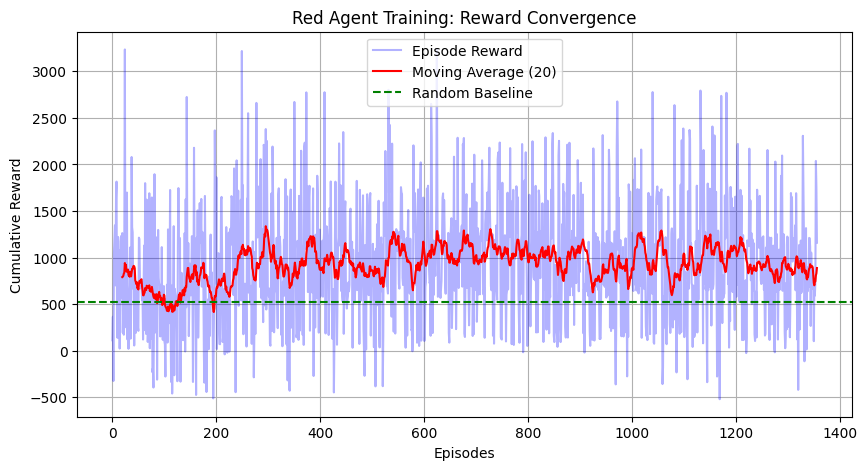

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history_callback.history, label='Episode Reward', alpha=0.3, color='blue')
plt.plot(pd.Series(history_callback.history).rolling(window=20).mean(), label='Moving Average (20)', color='red')
plt.axhline(y=baseline_results['mean_reward'], color='green', linestyle='--', label='Random Baseline')
plt.title('Red Agent Training: Reward Convergence')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True)
plt.show()

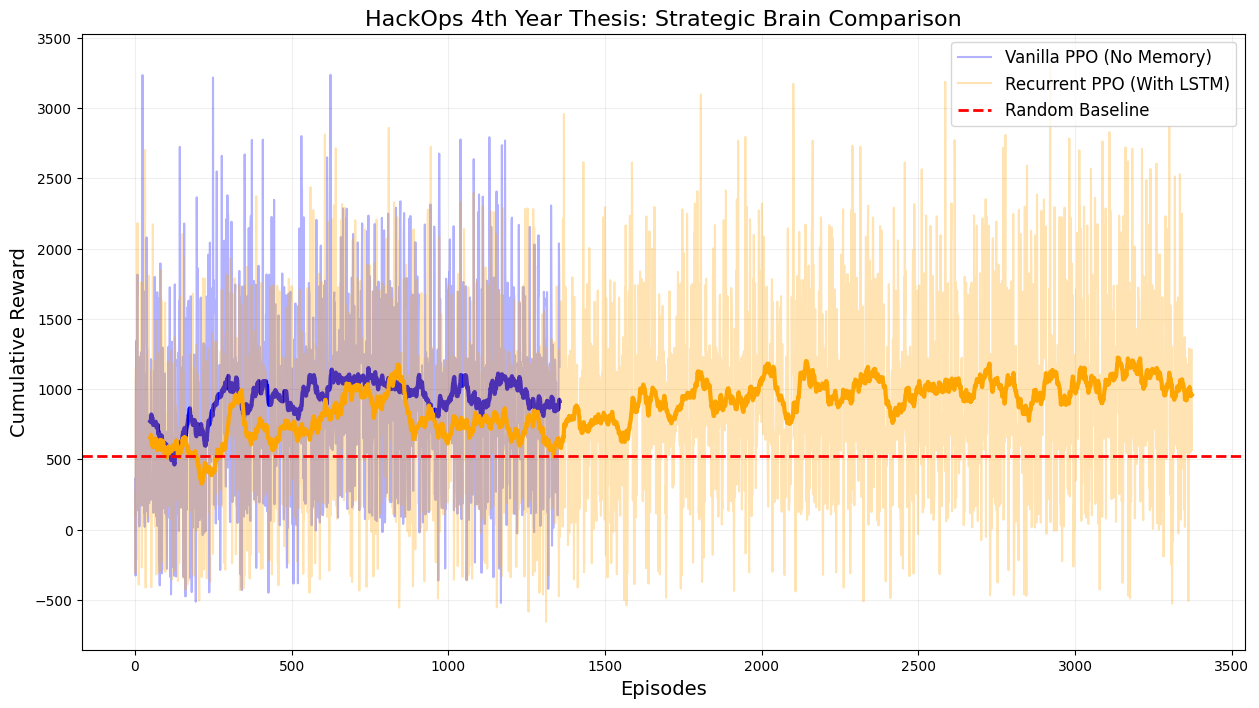

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# 1. Plot Vanilla PPO (from Step 3)
plt.plot(history_callback.history, label="Vanilla PPO (No Memory)", alpha=0.3, color='blue')
v_avg = pd.Series(history_callback.history).rolling(window=50).mean()
plt.plot(v_avg, color='blue', linewidth=3)

# 2. Plot Memory PPO (from Step 5)
plt.plot(history_callback_lstm.history, label="Recurrent PPO (With LSTM)", alpha=0.3, color='orange')
m_avg = pd.Series(history_callback_lstm.history).rolling(window=50).mean()
plt.plot(m_avg, color='orange', linewidth=3)

# 3. Plot Baseline (Horizontal Line)
plt.axhline(y=baseline_results['mean_reward'], color='red', linestyle='--', label="Random Baseline", linewidth=2)

plt.title("HackOps 4th Year Thesis: Strategic Brain Comparison", fontsize=16)
plt.xlabel("Episodes", fontsize=14)
plt.ylabel("Cumulative Reward", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

## 🏁 Step 6: Final Comparison

Compare the trained agent's metrics against the baseline side-by-side.

In [ ]:
print("Running Fresh Tournament Evaluation...")

eval_env = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])

mean_reward, std_reward = evaluate_policy(
    model, 
    eval_env, 
    n_eval_episodes=20, 
    deterministic=False 
)

print("\n" + "="*40)
print("        FINAL TOURNAMENT RESULTS")
print("="*40)
print(f"Random Agent:  {baseline_results['mean_reward']:.2f} reward")
print(f"Trained Agent: {mean_reward:.2f} (+/- {std_reward:.2f}) reward")
print("="*40)

improvement = ((mean_reward - baseline_results['mean_reward']) / abs(baseline_results['mean_reward'])) * 100
print(f"📈 Strategic Improvement: {improvement:.1f}%")

if mean_reward > baseline_results['mean_reward']:
    print("SUCCESS: The trained agent outperformed the baseline!")


DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775227859
Using seed: 1775227859
Using seed: 1775227859


Running Fresh Tournament Evaluation...

[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)


Using seed: 1775227859
Using seed: 1775227860
Using seed: 1775227860
Using seed: 1775227861
Using seed: 1775227861
Using seed: 1775227862
Using seed: 1775227862
Using seed: 1775227862
Using seed: 1775227862
Using seed: 1775227862
Using seed: 1775227863
Using seed: 1775227863
Using seed: 1775227863
Using seed: 1775227864
Using seed: 1775227864
Using seed: 1775227864
Using seed: 1775227865
Using seed: 1775227865
Using seed: 1775227865
Using seed: 1775227866



        FINAL TOURNAMENT RESULTS
Random Agent:  525.68 reward
Trained Agent: 1150.20 (+/- 612.43) reward
📈 Strategic Improvement: 118.8%
SUCCESS: The trained agent outperformed the baseline!


In [11]:
# Evaluate both models in fresh environments
eval_env = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])
print("Running Final Tournament (50 episodes per agent)...")

# Evaluate Vanilla
v_mean, v_std = evaluate_policy(model, eval_env, n_eval_episodes=50, deterministic=False)

# Evaluate Memory (LSTM)
m_mean, m_std = evaluate_policy(model_lstm, eval_env, n_eval_episodes=50, deterministic=False)

print("\n" + "="*50)
print("             FINAL TOURNAMENT RESULTS")
print("="*50)
print(f"1. Random Baseline:    {baseline_results['mean_reward']:>8.2f} reward")
print(f"2. Vanilla PPO Agent:  {v_mean:>8.2f} (+/- {v_std:0.2f}) reward")
print(f"3. Memory (LSTM) Agent: {m_mean:>8.2f} (+/- {m_std:0.2f}) reward")
print("="*50)

# Calculate which one is the "Best Brain"
best_score = max(v_mean, m_mean)
best_brain = "Memory (LSTM)" if m_mean > v_mean else "Vanilla PPO"
print(f"THE WINNER: {best_brain.upper()}")


DVWACybORG: Using scenario generator BaseScenarioGenerator



[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent


Using seed: 1775227866
Using seed: 1775227866
Using seed: 1775227866


   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)
Running Final Tournament (50 episodes per agent)...


Using seed: 1775227866
Using seed: 1775227866
Using seed: 1775227867
Using seed: 1775227867
Using seed: 1775227867
Using seed: 1775227867
Using seed: 1775227868
Using seed: 1775227868
Using seed: 1775227868
Using seed: 1775227869
Using seed: 1775227869
Using seed: 1775227869
Using seed: 1775227870
Using seed: 1775227870
Using seed: 1775227870
Using seed: 1775227871
Using seed: 1775227871
Using seed: 1775227871
Using seed: 1775227872
Using seed: 1775227872
Using seed: 1775227872
Using seed: 1775227872
Using seed: 1775227873
Using seed: 1775227873
Using seed: 1775227873
Using seed: 1775227874
Using seed: 1775227874
Using seed: 1775227874
Using seed: 1775227875
Using seed: 1775227875
Using seed: 1775227875
Using seed: 1775227876
Using seed: 1775227876
Using seed: 1775227876
Using seed: 1775227876
Using seed: 1775227877
Using seed: 1775227877
Using seed: 1775227877
Using seed: 1775227878
Using seed: 1775227878
Using seed: 1775227878
Using seed: 1775227879
Using seed: 1775227879
Using seed:


             FINAL TOURNAMENT RESULTS
1. Random Baseline:      525.68 reward
2. Vanilla PPO Agent:    814.84 (+/- 513.36) reward
3. Memory (LSTM) Agent:  1096.21 (+/- 628.86) reward
THE WINNER: MEMORY (LSTM)


### Step 7: Detailed Inference (Playback)

Run a single episode and see EXACTLY what the agent is doing at each step.

In [ ]:
import inspect
import os
from cyborg_integration import TrainedAgent

def run_detailed_inference(model_path, num_steps=20):
    print(f"Loading model for playback: {model_path}")
    
    # 1. Create environment
    env = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])
    model = PPO.load(model_path)
    
    # 2. Get the real internal environment components
    cyborg = env.unwrapped.env.env.env
    interface = cyborg.environment_controller.agent_interfaces['red_agent_0']
    action_space = interface.action_space
    
    # 3. Initialize TrainedAgent and build action map
    # We pass the model_path to ensure the class loads the correct weights
    trained_agent = TrainedAgent(model_path=model_path)
    possible_actions = trained_agent._get_possible_actions(action_space)
    
    print(f"Environment Ready. Action Space Size: {len(possible_actions)}")
    print("-" * 50)
    
    obs, info = env.reset()
    
    # Show Generated Vulnerabilities for this specific run
    print("Episode Generated Vulnerabilities:")
    active_vulns = cyborg.environment_controller.state.active_vulns
    for vid, vinfo in active_vulns.items():
        print(f"   - {vid:<15} | Severity: {vinfo.get('severity', 'N/A'):<8} | Page: {vinfo.get('location', 'N/A')}")
    print("-" * 50)
    
    total_reward = 0
    for step in range(1, num_steps + 1):
        # Predict index - Deterministic=False allows the brain to be more flexible
        action_idx, _ = model.predict(obs, deterministic=False) 
        
        # Translate the index to a human-readable Action string
        action_obj = possible_actions[action_idx]
        action_str = str(action_obj)
        
        # Execute the action on the environment
        obs, reward, terminated, truncated, info = env.step(action_idx)
        total_reward += reward
        
        # Determine status description
        status = "SUCCESS" if reward > 10 else "INFO"
        if reward < 0: status = "PENALTY"
        
        print(f"Step {step:02d}: Action = {action_str:<40} | Reward = {reward:>5.1f} | {status}")
        
        if terminated or truncated:
            print("-" * 50)
            print(f"Episode Finished! Total Reward: {total_reward:.2f}")
            break
            
    if not (terminated or truncated):
        print("-" * 50)
        print(f"Reached step limit. Total Reward: {total_reward:.2f}")

run_detailed_inference(os.path.join(MODELS_DIR, "red_agent_final.zip"))

DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775227904
Using seed: 1775227904


Loading model for playback: d:\study\4th year 1st term\Graduation Project\hackops-project\api\models\red_agent\red_agent_final.zip

[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)


Using seed: 1775227905


Environment Ready. Action Space Size: 82
--------------------------------------------------
Episode Generated Vulnerabilities:
   - sqli_login      | Severity: critical | Page: /login.php
   - sqli_search     | Severity: high     | Page: /products.php
   - sqli_detail     | Severity: high     | Page: /search.php
   - sqli_blind      | Severity: high     | Page: /profile.php
   - sqli_admin      | Severity: critical | Page: /admin_dashboard.php
   - xss_stored_support | Severity: high     | Page: /search.php
   - sqli_register   | Severity: high     | Page: /support.php
   - xss_reflected_login | Severity: low      | Page: /register.php
--------------------------------------------------
Step 01: Action = Fuzz /index.php (XSS)                    | Reward =  -0.5 | PENALTY
Step 02: Action = SmartExploit /product_detail.php (SQLi)  | Reward = -15.0 | PENALTY
Step 03: Action = Fuzz /orders.php (SQLi)                  | Reward =  -0.5 | PENALTY
Step 04: Action = Fuzz /cart.php (SQLi)        

In [ ]:
import os
import numpy as np
import time
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from cyborg_integration import TrainedAgent

def run_battleground(vanilla_path, lstm_path, num_steps=25, seed=42):
    print(f"🎭 SCENARIO SEED: {seed} (Forcing Same Start for Both!)")
    print("-" * 65)
    
    # 1. LOAD MODELS
    model_vanilla = PPO.load(vanilla_path)
    model_lstm = RecurrentPPO.load(lstm_path)
    
    # 2. RUN VANILLA (The Reactor)
    print("\n🕵️ AGENT 1: Vanilla PPO (The Reactor)")
    print("-" * 65)
    env_v = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])
    obs_v, _ = env_v.reset(seed=seed) 
    
    trained_v = TrainedAgent(model_path=vanilla_path)
    cyborg_v = env_v.unwrapped.env.env.env
    actions_v = trained_v._get_possible_actions(cyborg_v.environment_controller.agent_interfaces['red_agent_0'].action_space)
    
    reward_v = 0
    for step in range(1, num_steps + 1):
        action, _ = model_vanilla.predict(obs_v, deterministic=False)
        obs_v, r, done, trunc, _ = env_v.step(action)
        reward_v += r
        print(f"Step {step:02d}: {str(actions_v[action]):<40} | Reward: {r:>5.1f}")
        if done or trunc: break
    print(f"🏁 Vanilla Total Reward: {reward_v:.2f}")

    print("\n" + "="*65)

    # 3. RUN LSTM (The Strategist)
    print("\n🧠 AGENT 2: Recurrent PPO (The Strategist)")
    print("-" * 65)
    env_m = train_sb3.create_training_env('red', ['XSS', 'SQL Injection'])
    obs_m, _ = env_m.reset(seed=seed)
    
    trained_m = TrainedAgent(model_path=lstm_path)
    cyborg_m = env_m.unwrapped.env.env.env
    actions_m = trained_m._get_possible_actions(cyborg_m.environment_controller.agent_interfaces['red_agent_0'].action_space)
    
    reward_m = 0
    lstm_state = None
    
    for step in range(1, num_steps + 1):
        action, lstm_state = model_lstm.predict(obs_m, state=lstm_state, deterministic=False)
        obs_m, r, done, trunc, _ = env_m.step(action)
        reward_m += r
        print(f"Step {step:02d}: {str(actions_m[action]):<40} | Reward: {r:>5.1f}")
        if done or trunc: break
    print(f"🏁 Memory (LSTM) Total Reward: {reward_m:.2f}")

run_battleground(
    os.path.join(MODELS_DIR, "red_agent_final.zip"),
    os.path.join(MODELS_DIR_LSTM, "red_agent_lstm_final.zip")
)

DVWACybORG: Using scenario generator BaseScenarioGenerator


🎭 SCENARIO SEED: 42 (Forcing Same Start for Both!)
-----------------------------------------------------------------

🕵️ AGENT 1: Vanilla PPO (The Reactor)
-----------------------------------------------------------------

[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent


Using seed: 1775227905
Using seed: 1775227905
Using seed: 1775227905


   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)
Step 01: SmartExploit /search.php (XSS)           | Reward: -15.0
Step 02: Fuzz /product_detail.php                 | Reward:  -0.5
Step 03: Fuzz /orders.php (SQLi)                  | Reward:  -0.5
Step 04: SmartExploit /reviews.php (XSS)          | Reward: -15.0
Step 05: SmartExploit /register.php (XSS)         | Reward: -15.0
Step 06: SmartExploit /support.php (XSS)          | Reward: -15.0
Step 07: Fuzz /admin_login.php (SQLi)             | Reward:  -0.5
Step 08: Directory Discovery                      | Reward:  15.0
Step 09: SmartExploit /cart.php (SQLi)            | Reward: -15.0
Step 10: SmartExploit /support.php (XSS)          | Reward: -15.0
Step 11: SmartExploit /products.php (SQLi)        | Reward: -15.0
Step 12: SmartExploit /profile.php (XSS)          | Reward: -15.0
Step 13: Fuzz /admin_login.php (SQLi)             | Reward:  -0.5
Step 14: 

DVWACybORG: Using scenario generator BaseScenarioGenerator
Using seed: 1775227905
Using seed: 1775227905
Using seed: 1775227905


Step 25: Fuzz /support.php (XSS)                  | Reward:  -0.5
🏁 Vanilla Total Reward: -84.50


🧠 AGENT 2: Recurrent PPO (The Strategist)
-----------------------------------------------------------------

[Env] Creating environment for red agent...
   [Opponent] Using Random Blue opponent
   [OK] Environment created
   Agent: red_agent_0
   Observation space: Box(-1.0, 3.0, (60,), float32)
   Action space: Discrete(82)
Step 01: SmartExploit /index.php (XSS)            | Reward: -15.0
Step 02: SmartExploit /index.php (XSS)            | Reward: -18.0
Step 03: Fuzz /admin_dashboard.php (XSS)          | Reward:  -0.5
Step 04: SmartExploit /products.php (SQLi)        | Reward: -15.0
Step 05: Fuzz /admin_dashboard.php (SQLi)         | Reward: -10.0
Step 06: Fuzz /orders.php (SQLi)                  | Reward:  -0.5
Step 07: Fuzz /search.php (SQLi)                  | Reward:  50.0
Step 08: SmartExploit /search.php (SQLi)          | Reward: 500.0
Step 09: Fuzz /index.php (SQLi)               

## Conclusion

You have successfully trained a Red Agent that can identify and exploit vulnerabilities in a simulated DVWA environment. The agent learned to prioritize high-reward vulnerabilities while avoiding redundant actions that incur penalties.